# Markov Chain Monte Carlo

## The Problem

We want to draw samples $x_1, \ldots, x_N$ from a probability distribution $p(x)$, but we only have access to an **unnormalized** version:

$$p(x) = \frac{1}{Z}\,\tilde{p}(x), \qquad Z = \int \tilde{p}(x)\,dx $$

The canonical example is Bayesian inference, where

$$p(x \mid y) = \frac{p(y \mid x)\,p(x)}{p(y)}$$

and $p(y) = \int p(y \mid x)\,p(x)\,dx$ is a high-dimensional integral we cannot compute.

Once we have samples, we can estimate any expectation via

$$\mathbb{E}_{x \sim p}[f(x)] = \int f(x)\,p(x)\,dx \;\approx\; \frac{1}{N}\sum_{i=1}^N f(x_i)$$

In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

rng = np.random.default_rng(100)

## 1. Target Distribution

We work with an **unnormalized bimodal mixture of Gaussians** as our running example:

$$\tilde{p}(x) = \exp\!\left(-\frac{(x-3)^2}{2}\right) + \exp\!\left(-\frac{(x+3)^2}{2}\right)$$


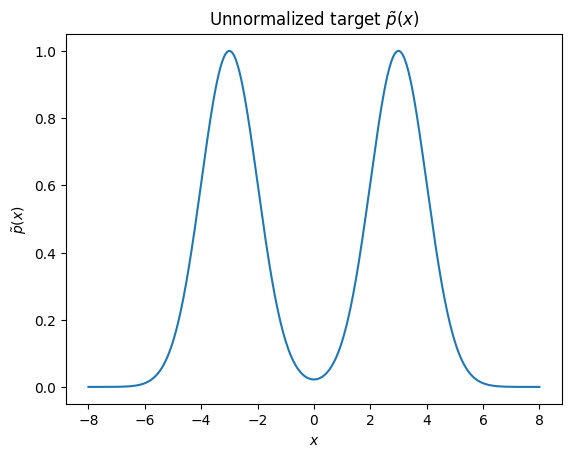

In [3]:
def p_tilde(x):
    return np.exp(-0.5*(x - 3)**2) + np.exp(-0.5*(x + 3)**2)

x_grid = np.linspace(-8, 8, 500)

plt.plot(x_grid, p_tilde(x_grid))
plt.title(r"Unnormalized target $\tilde{p}(x)$")
plt.xlabel("$x$"); plt.ylabel(r"$\tilde{p}(x)$")
plt.show()

## 2. Rejection Sampling

Choose a **proposal distribution** $g(x)$ from which we can sample easily, and a constant $M > 0$ such that

$$M\,g(x) \geq \tilde{p}(x), \quad \forall x$$

**Algorithm:**
1. Sample $\hat{x} \sim g(x)$
2. Accept $\hat{x}$ with probability
$$\alpha(\hat{x}) = \dfrac{\tilde{p}(\hat{x})}{M\,g(\hat{x})}$$

3. Repeat until enough samples are accepted


In [23]:
G_LOC, G_SCALE = 0.0, 5.0
g = scipy.stats.norm(loc=G_LOC, scale=G_SCALE)
u = scipy.stats.uniform()
import random

In [30]:
def rejection_sampling(n_samples, M, proposal_distribution):

    p = proposal_distribution

    accepted = []
    n_samples_generated = 0
    while (len(accepted) < n_samples):
        x = p.rvs()
        alpha = p_tilde(x)/(M*p.pdf(x))
        n_samples_generated += 1
        while random.random() > alpha:
            x = p.rvs()
            alpha = p_tilde(x)/(M*p.pdf(x))
            n_samples_generated += 1
        accepted.append(x)

    return np.array(accepted), n_samples_generated

Acceptance rate: 31.16%


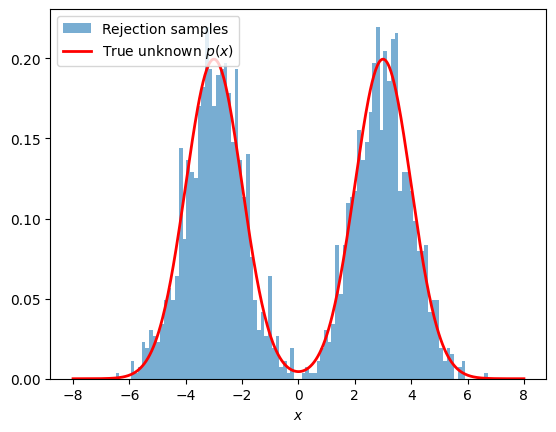

In [36]:
M = 16.0
samples_rs, n_samples_generated = rejection_sampling(2000, M, g)
print(f"Acceptance rate: {2000/n_samples_generated:.2%}")
plt.hist(samples_rs, bins=100, density=True, alpha=0.6, label="Rejection samples")

Z = 2 * np.sqrt(2 * np.pi)
plt.plot(x_grid, p_tilde(x_grid)/Z, 'r', lw=2, label=r"True unknown $p(x)$")

plt.legend()
plt.xlabel("$x$")
plt.show()

## 3. Monte Carlo Markov Chain: Metropolis-Hastings

Fix a **proposal kernel** $ q( x_{t+1} \mid x_{t})$ which satisfies the detailed balance condition.

**Algorithm:**
1. Sample $ x_{t+1}\sim q(x_{t+1} \mid x_{t} )$
2. Accept $x_{t+1}$ with probability

$$\alpha(x_{t+1} \mid x_{t}) = \min\!\left(1,\; \frac{\tilde{p}(x_{t+1})}{\tilde{p}(x_{t})}\right)$$

3. Otherwise, $x_{t+1} = x_{t}$




In [ ]:
def metropolis_hastings(n_steps, sigma, x0=0.0):

    g = scipy.stats.norm(loc = x0, scale = sigma)
    x = g.rvs()
    
    chain = []

    for _ in range (n_steps):
        g = scipy.stats.norm(loc = x)
        x_n = g.rvs()
        alpha = min(1, p_tilde(x_n)/p_tilde(x))
        while random.random() > alpha:
            x_n = g.rvs()
            alpha = min(1, p_tilde(x_n)/p_tilde(x))
        
        chain.append(x_n)
        x = x_n

    return np.array(chain)

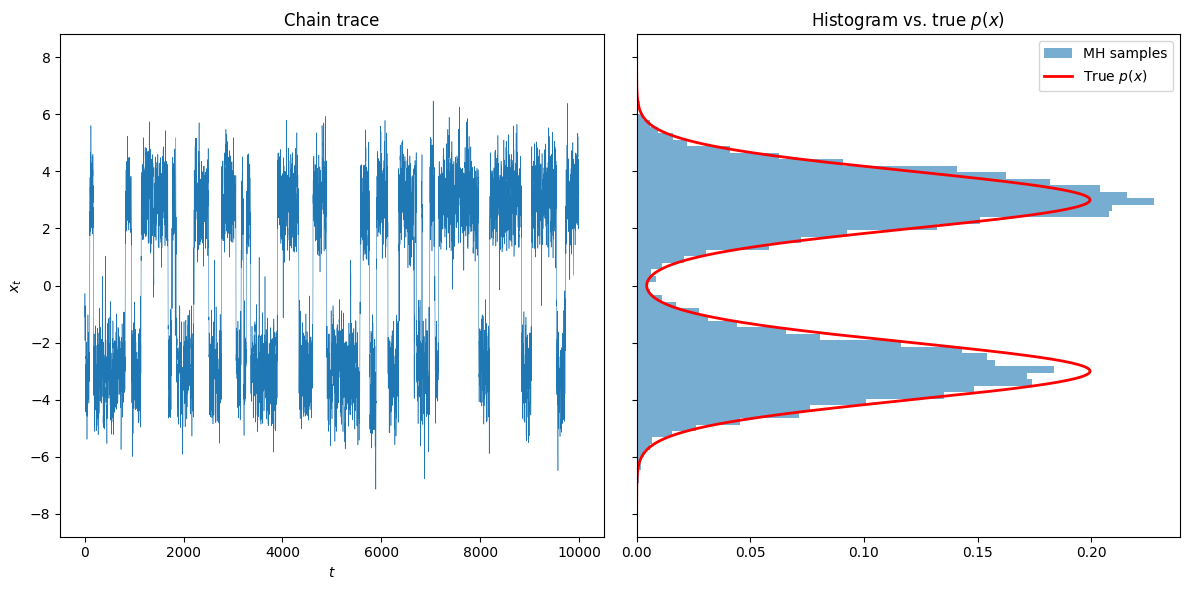

In [46]:
n_steps = 10000
chain = metropolis_hastings(n_steps, sigma=2.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].plot(chain, lw=0.4)
axes[0].set_title("Chain trace")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("$x_t$")

axes[1].hist(chain, bins=60, density=True, alpha=0.6, label="MH samples", orientation="horizontal")
axes[1].plot(p_tilde(x_grid)/Z, x_grid, 'r', lw=2, label=r"True $p(x)$",)
axes[1].legend()
axes[1].set_title("Histogram vs. true $p(x)$")
plt.tight_layout()
plt.show()

## 4. Diagnostics

### Burn-in

The chain starts at an arbitrary $x_0$ and needs time to reach stationarity. We discard the first $n_{\text{burn}}$ samples (**warm-up phase**).

### Autocorrelation

Consecutive samples $x_t, x_{t+1}$ are correlated. Define the **autocorrelation at lag** $k$:

$$\rho_k := \mathrm{Corr}[x_t,\, x_{t+k}]$$

High $\rho_k$ for many lags means slow mixing.

### Effective Sample Size

Because of autocorrelation, $N$ chain samples are not equivalent to $N$ i.i.d. samples. The effective sample size is

$$n_{\text{eff}} = \frac{N}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

A rule of thumb: aim for $n_{\text{eff}} \geq 100$.

### $\hat{R}$ Convergence Diagnostic

Run $m$ chains from overdispersed starting points. Define within-chain variance $W$ and between-chain variance $B$. Then

$$\hat{R} := \sqrt{\frac{\mathrm{VAR}^+[\Psi]}{W}}, \qquad \mathrm{VAR}^+[\Psi] = \frac{n-1}{n}W + \frac{1}{n}B$$

$\hat{R} > 1$ and $\hat{R} \xrightarrow{n\to\infty} 1$. Convergence is declared when $\hat{R} \leq 1.1$.

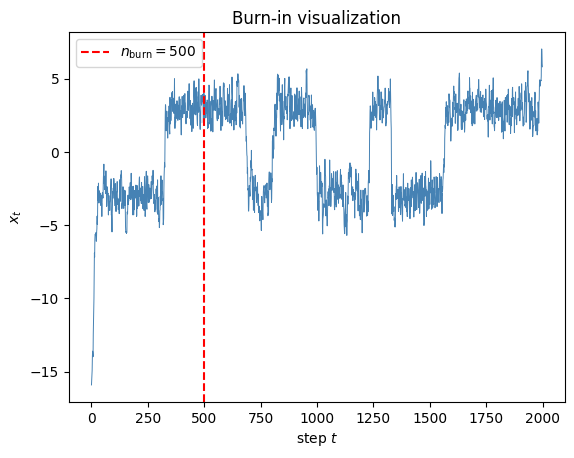

In [40]:
chain_vis = metropolis_hastings(2000, sigma=2.0, x0=-15.0)
plt.plot(chain_vis, lw=0.7, color='steelblue')
plt.axvline(500, color='r', linestyle='--', label=r"$n_{\rm burn}=500$")
plt.xlabel("step $t$")
plt.ylabel("$x_t$")
plt.legend()
plt.title("Burn-in visualization")
plt.show()

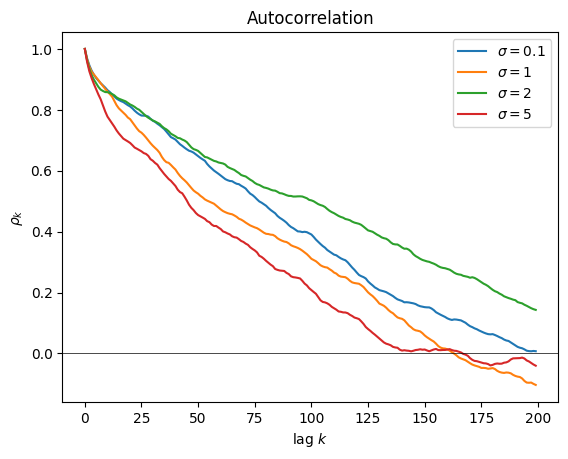

In [41]:
def autocorr(x, max_lag=200):
    x = x - x.mean()
    ac = np.correlate(x, x, mode='full')
    ac = ac[len(ac)//2:]
    return ac[:max_lag] / ac[0]


for label, sigma in [("$\\sigma=0.1$", 0.1), ("$\\sigma=1$", 1.0), ("$\\sigma=2$", 2.0), ("$\\sigma=5$", 5.0)]:
    c = metropolis_hastings(2000, sigma=sigma)
    plt.plot(autocorr(c[1000:]), label=label)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("lag $k$"); plt.ylabel(r"$\rho_k$")
plt.title("Autocorrelation")
plt.legend()
plt.show()

## 6. Monte Carlo Markov Chain: Hamiltonian Monte Carlo

The key weakness of MH is that the random-walk proposal ignores the geometry of $p$. HMC fixes this by introducing momentum variables $y$ and following Hamiltonian dynamics to make large, directed moves.

### Setup

Define the **Hamiltonian** (total energy):

$$H(x, y) = U(x) + K(y), \qquad U(x) = -\log\tilde{p}(x), \quad K(y) = \tfrac{1}{2}y^2$$

The joint distribution $p(x, y) \propto \exp(-H(x,y))$ factorizes: marginalizing out $y$ gives back $p(x)$.

### Equations of Motion

Hamiltonian dynamics keep $H$ constant and are governed by:

$$\dot{x} = \nabla_y H(x,y) = \nabla_y K(y) = y, \qquad \dot{y} =-\nabla_x H(x,y)= -\nabla_x U(x) = \nabla_x \log\tilde{p}(x)$$

We integrate these numerically for $L$ steps of size $\varepsilon$ using the **leapfrog** scheme:

$$y_{1/2} = y + \tfrac{\varepsilon}{2}\,\nabla_x\log\tilde{p}(x)$$
$$x' = x + \varepsilon\, y_{1/2}$$
$$y' = y_{1/2} + \tfrac{\varepsilon}{2}\,\nabla_x\log\tilde{p}(x')$$

### Algorithm

1. Sample $y \sim \mathcal{N}(0,1)$ (randomize momentum)
2. Run $L$ leapfrog steps from $(x, y)$ to get $(x', y')$
3. Accept $(x', y')$ with the MH criterion

$$\alpha = \min\!\left(1,\; \exp\!\bigl(H(x,y) - H(x',y')\bigr)\right)$$

Because leapfrog is nearly energy-conserving, acceptance rates are typically very high. The chain makes **large jumps** rather than a random walk, giving much lower autocorrelation.

In [71]:
def grad_log_p_tilde(x):
    e1 = np.exp(-0.5*(x - 3)**2)
    e2 = np.exp(-0.5*(x + 3)**2)
    return (-(x-3)*e1 - (x+3)*e2) / (e1 + e2)

def hamiltonian(x, y):
    return -np.log(p_tilde(x)) + 0.5*y**2

def leapfrog(x, y, epsilon, L):
    y = y + 0.5*epsilon * grad_log_p_tilde(x)
    for _ in range(L - 1):
        x = x + epsilon * y
        y = y + epsilon * grad_log_p_tilde(x)
    x = x + epsilon * y
    y = y + 0.5*epsilon * grad_log_p_tilde(x)
    return x, y

In [ ]:
def hmc(n_steps, epsilon=0.3, L=20, x0=0.0):
    chain = []
    m_chain = []

    z = scipy.stats.norm(loc = 0, scale = 1)
    x = x0
    y = z.rvs()
    
    for _ in range(n_steps):

        y = z.rvs() # try not to reset the value at each step : it become really interesting
        x_n, y_n = leapfrog(x, y, epsilon, L)
        alpha = min(1, np.exp(hamiltonian(x, y) - hamiltonian(x_n, y_n)))
        while random.random() > alpha:
            x_n, y_n = leapfrog(x, y, epsilon, L)
            alpha = min(1, np.exp(hamiltonian(x, y) - hamiltonian(x_n, y_n)))
        chain.append(x_n)
        m_chain.append(y_n)
        x, y = x_n, y_n
        
    return chain, m_chain

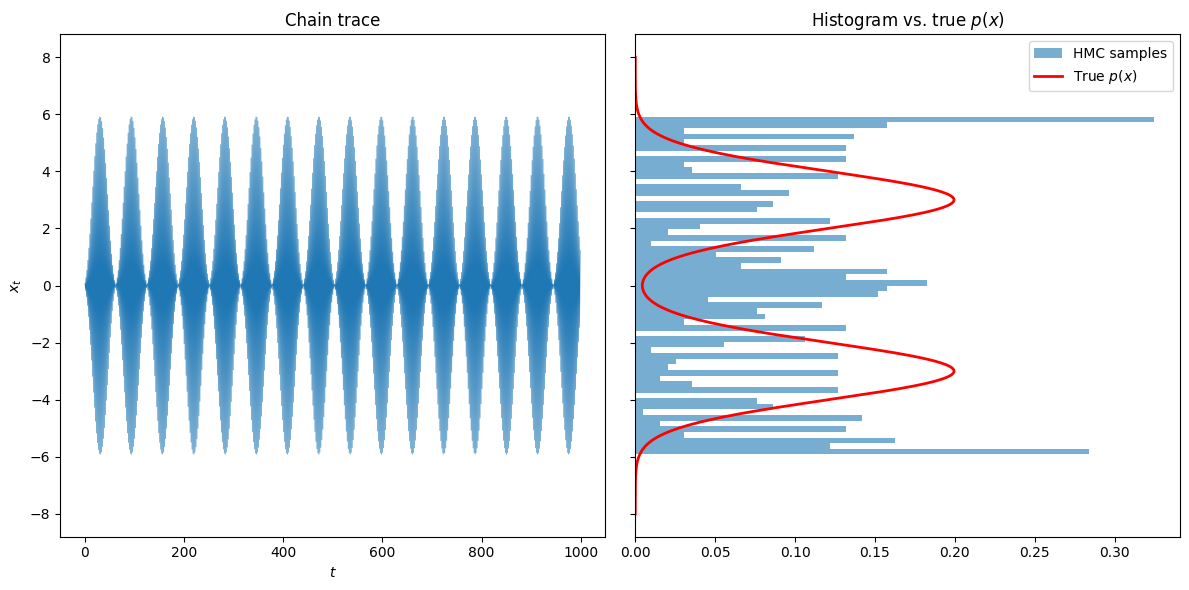

In [87]:
n_steps = 1000
chain, m_chain= hmc(n_steps)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].plot(chain, lw=0.4)
axes[0].set_title("Chain trace")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("$x_t$")

axes[1].hist(chain, bins=60, density=True, alpha=0.6, label="HMC samples", orientation="horizontal")
axes[1].plot(p_tilde(x_grid)/Z, x_grid, 'r', lw=2, label=r"True $p(x)$",)
axes[1].legend();
axes[1].set_title("Histogram vs. true $p(x)$")

plt.tight_layout(); plt.show()

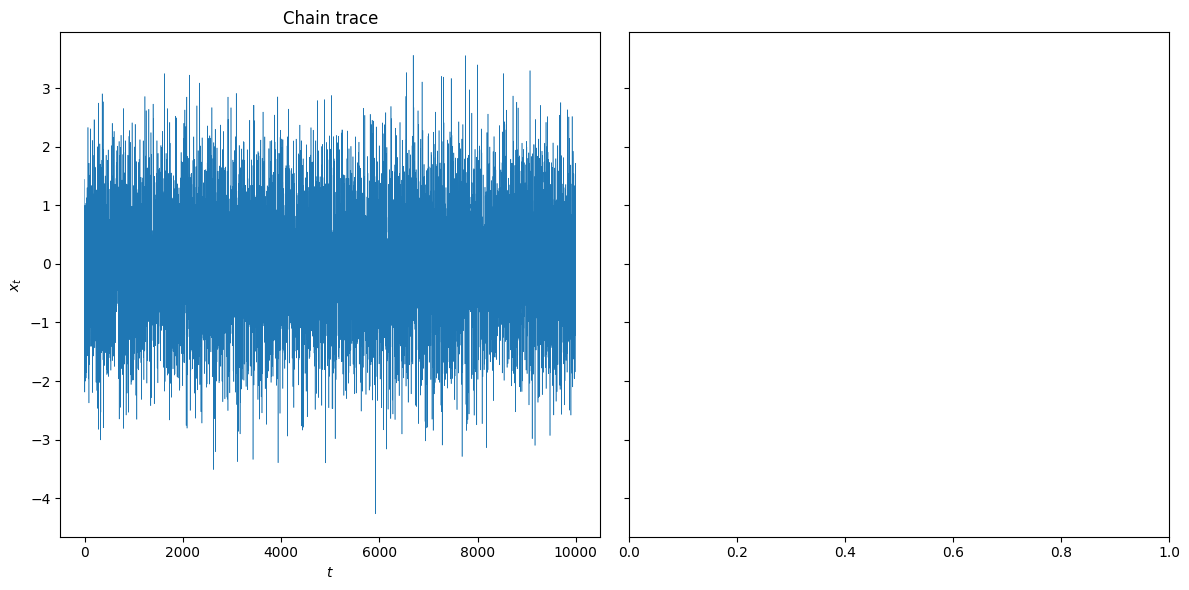

In [82]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].plot(m_chain, lw=0.4)
axes[0].set_title("Chain trace")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("$x_t$")

plt.tight_layout(); plt.show()